### confusion matrices

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from matplotlib.colors import TwoSlopeNorm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

def create_confusion_matrix(data, species, label_map=None):
    """
    Creates a confusion matrix from detection results using GT derived from filename.

    Args:
        data: list of results entries from results.json
        species: list of species names in order of class indices
        label_map: optional dict to map class names to display labels

    Returns:
        cm: (num_classes + 1) x (num_classes + 1) confusion matrix
            Rows = ground truth classes
            Columns = predicted classes
            Last row = background FP
            Last column = missed GT (FN)
        labels: list of display labels including "background"
    """
    num_classes = len(species)
    cm = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

    # Default label map
    if label_map is None:
        label_map = {cls: cls for cls in species}
    labels = [label_map.get(cls, cls) for cls in species] + [label_map.get("background", "background")]

    for entry in data:
        filename = entry["filename"]
        # Derive GT class from filename; fallback to last index if unknown
        row_index = next((i for i, sp in enumerate(species) if filename.startswith(sp)), num_classes)

        # True positives (correct predictions)
        for cls_id in entry["true_positives"]["classes"]:
            cm[row_index, cls_id] += 1

        # False negatives (missed GT objects)
        cm[row_index, num_classes] += len(entry["false_negatives"]["classes"])

        # False positives
        for cls_id in entry["false_positives"]["classes"]:
            if cls_id == row_index:
                # Background FP (wrong location for correct class)
                cm[num_classes, cls_id] += 1
            else:
                # Misclassification (wrong class)
                cm[row_index, cls_id] += 1

    return cm, labels


def normalize_confusion_matrix(cm, axis=1):
    """
    Normalize a confusion matrix.

    Parameters
    ----------
    cm : list[list[int]] or np.ndarray
        The confusion matrix.
    axis : int
        Axis to normalize over:
        - 1 = rows (normalize by true class → each row sums to 1)
        - 0 = columns (normalize by predicted class → each column sums to 1)
        - None = normalize by total sum

    Returns
    -------
    np.ndarray
        Normalized confusion matrix (float values).
    """
    cm = np.array(cm, dtype=float)
    if axis is None:
        total = cm.sum()
        return cm / total if total > 0 else cm
    else:
        sums = cm.sum(axis=axis, keepdims=True)
        sums[sums == 0] = 1  # avoid division by zero
        return cm / sums


def plot_confusion_matrix(cm, labels, output_path=None, title="Confusion Matrix"):
    """
    Plot a confusion matrix with provided labels.

    Args:
        cm: 2D array
        labels: list of display labels (including background)
        output_path: optional path to save figure
        title: figure title
    """
    df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    plt.imshow(df, interpolation="nearest", cmap="Blues")
    plt.title(title, fontsize = 12)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right", fontsize = 12)
    plt.yticks(tick_marks, labels, fontsize = 12)

    # annotate counts
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(
                j, i, df.iat[i, j],
                ha="center", va="center",
                color="white" if df.iat[i, j] > df.values.max()/2 else "black",
                fontsize = 12
            )

    plt.ylabel("True Species", fontsize = 12)
    plt.xlabel("Predicted Species", fontsize = 12)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    plt.show()


def give_confusion_infos(file, species, label_map=None, output_path=None, include_thrips=True):
    """
    Load results, create confusion matrix, normalize, and plot with optional label mapping.
    Can optionally skip the 'Thrips' class.
    """
    with open(file, "r") as f:
        data = json.load(f)

    # create confusion matrix
    cm, labels = create_confusion_matrix(data, species, label_map=label_map)

    # Optionally remove 'Thrips'
    if not include_thrips:
        if label_map and "FRANOC" in label_map:
            thrips_label = label_map["FRANOC"]
        else:
            thrips_label = "FRANOC"  # fallback
        if thrips_label in labels:
            idx = labels.index(thrips_label)
            cm = np.delete(cm, idx, axis=0)  # remove row
            cm = np.delete(cm, idx, axis=1)  # remove column
            labels = [l for i,l in enumerate(labels) if i != idx]

    print("Confusion Matrix with FP/FN (last row = FP, last col = FN):\n", cm)

    # Normalize
    norm_cm_row = normalize_confusion_matrix(cm, axis=1)
    norm_cm_col = normalize_confusion_matrix(cm, axis=0)

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    for ax, norm_cm, title in zip(
        axes,
        [norm_cm_row, norm_cm_col],
        ["Recall for self-training on validation set", "Precision for for self-training on validation set"]
    ):
        df = pd.DataFrame(np.round(norm_cm, 2), index=labels, columns=labels)
        im = ax.imshow(df, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize = 12)
        ax.set_yticklabels(labels, fontsize = 12)
        ax.set_ylabel("True Species", fontsize = 12)
        ax.set_xlabel("Predicted Species", fontsize = 12)

        # annotate cells
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(
                    j, i, f"{df.iat[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if df.iat[i, j] > df.values.max()/2 else "black",
                    fontsize=12
                )

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Normalized Value")
    if output_path:
        plt.savefig(output_path)
    plt.show()

    return norm_cm_row, norm_cm_col


species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
label_map = {
    "BRAIIM": "Fungus gnats",
    "LIRIBO": "Leaf miner flies",
    "FRANOC": "Thrips",
    "TRIAVA": "Whiteflies",
    "background": "Background"
}

In [13]:
def plot_confusion_matrix_differences(norm_cm_row_1, norm_cm_row_2,
                                      norm_cm_col_1, norm_cm_col_2,
                                      species, output_path = None):
    """
    Plot the differences between two sets of normalized confusion matrices
    (row- and column-normalized) with intuitive coloring:

    - Diagonal ↑ = green (improvement), ↓ = red (worse)
    - Off-diagonal ↑ = red (worse), ↓ = green (improvement)
    - Color range automatically scaled to actual data range
    """

    labels = species + ["background"]

    # Compute differences
    diff_row = np.round(norm_cm_row_2 - norm_cm_row_1, 3)
    diff_col = np.round(norm_cm_col_2 - norm_cm_col_1, 3)

    # Make figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, diff_cm, title in zip(
        axes,
        [diff_row, diff_col],
        ["Δ Row-normalized (Recall change)", "Δ Column-normalized (Precision change)"]
    ):
        df = pd.DataFrame(diff_cm, index=labels, columns=labels)

        # Invert off-diagonal meaning (since increases in misclassifications are bad)
        adjusted = df.copy()
        for i in range(len(labels)):
            for j in range(len(labels)):
                if i != j:
                    adjusted.iat[i, j] = -adjusted.iat[i, j]

        # Compute color limits dynamically
        vmin, vmax = adjusted.values.min(), adjusted.values.max()
        vlim = max(abs(vmin), abs(vmax))  # symmetric around zero

        # Use a centered diverging colormap: red↔white↔green
        norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
        im = ax.imshow(adjusted, interpolation="nearest", cmap="RdYlGn", norm=norm)

        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True Species")
        ax.set_xlabel("Predicted Species")

        # Annotate numeric values (+/-)
        for i in range(len(labels)):
            for j in range(len(labels)):
                val = df.iat[i, j]
                if abs(val) > 0.005:
                    ax.text(
                        j, i, f"{val:+.2f}",
                        ha="center", va="center",
                        color="black",
                        fontsize=8
                    )

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Green = improvement, Red = degradation", rotation=270, labelpad=20)
    if output_path: plt.savefig(output_path)
    plt.show()


species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]


### best supervised on full images

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1346   17    0    0  671]
 [   0 1249    9    0   87]
 [   0    5  779    1  736]
 [   0    0    2 1958  755]
 [  94   31  196  144    0]]


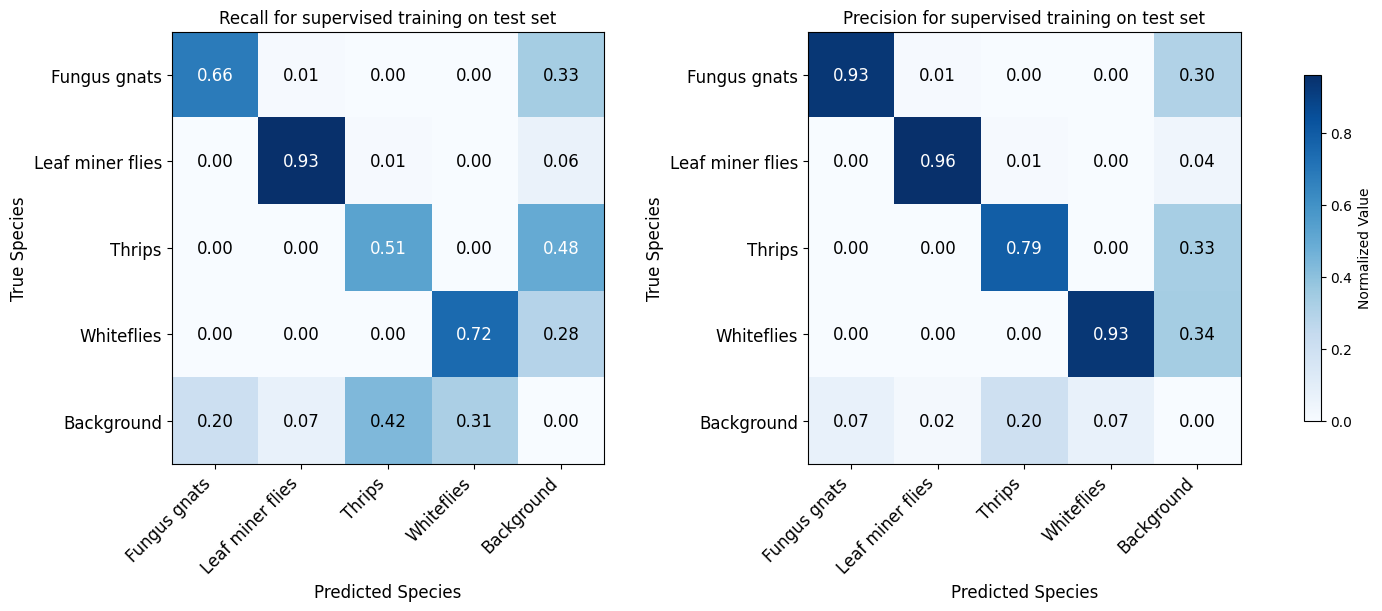

In [14]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train6_test_set/results.json"
_,_ = give_confusion_infos(file, species,  label_map,"/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train6_test_set/confusion.png")

### same on val set

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 851    3    2    0  146]
 [   0 1042    3    0   12]
 [   0    6  458    3  281]
 [   0    2    1 1190  287]
 [  94   59  184  129    0]]


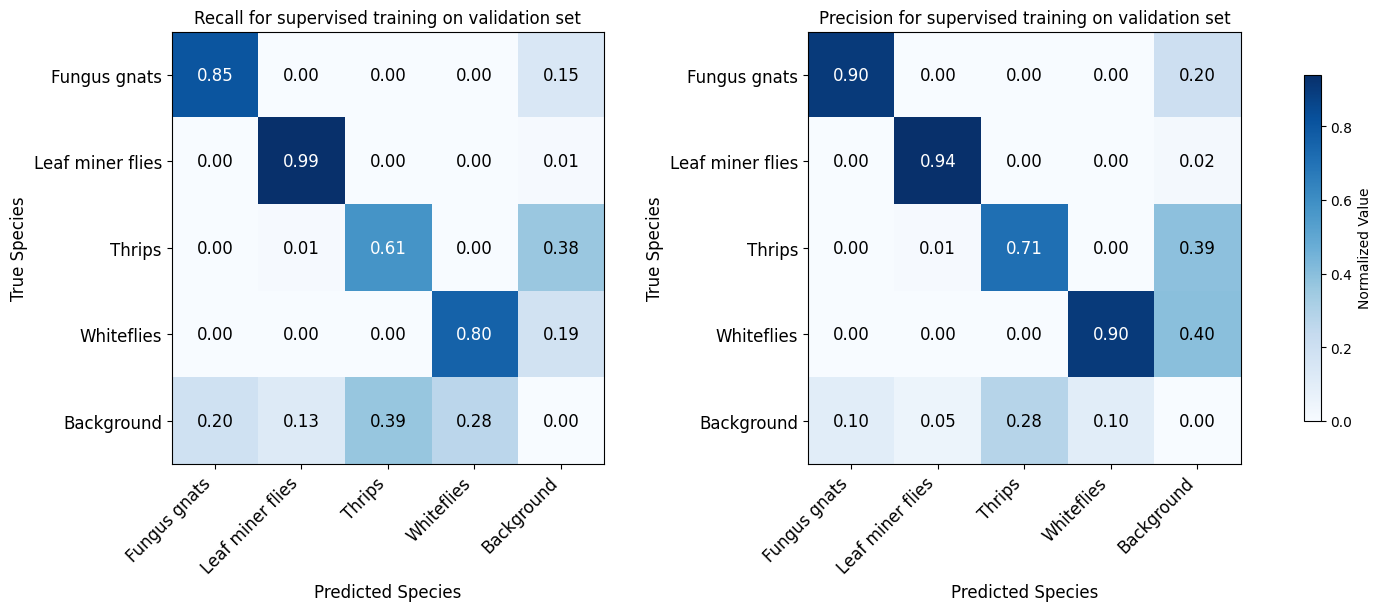

In [16]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train6_val_set/results.json"
c1, c2 = give_confusion_infos(file,  species,  label_map,output_path = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train6/supervised_confusion_val_set.png")

### best supervised on tiles

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1278   32    1    0  739]
 [  14 1214   14    7  109]
 [   1    5  834    4  681]
 [   0    0    5 2052  659]
 [  76   18  118  122    0]]


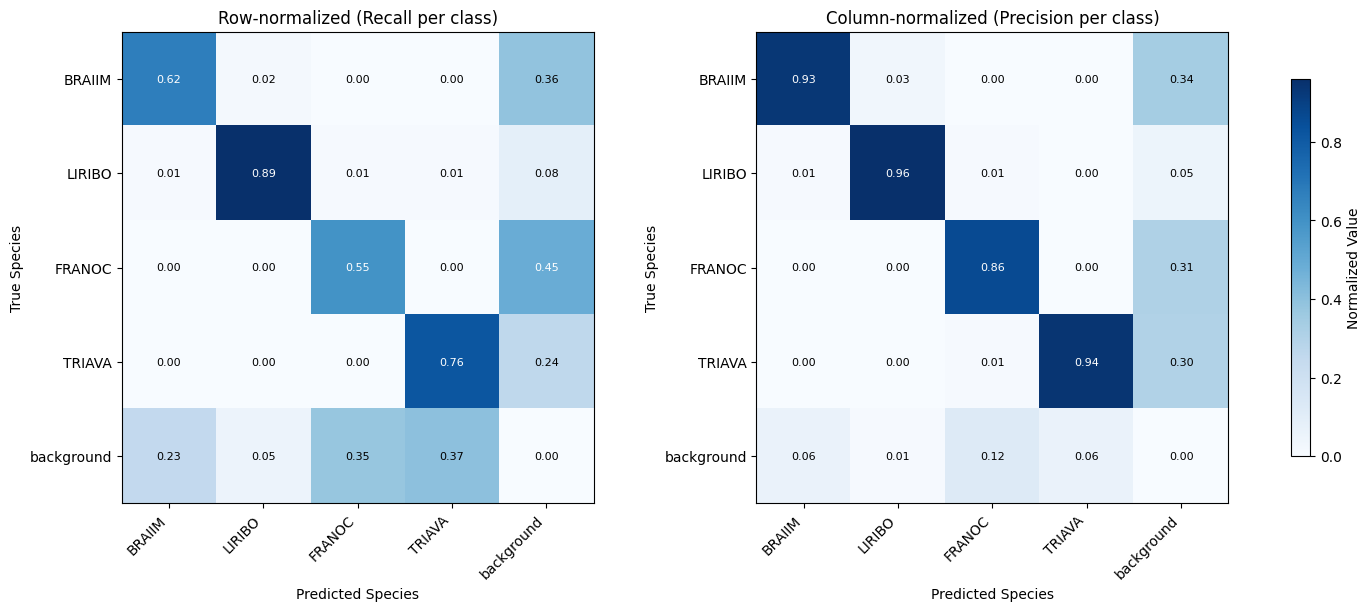

In [ ]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train4_test_set/results.json"
c1,c2 = give_confusion_infos(file, output_path = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train4_test_set/confusions.png")

### best self-training overall

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1292   27    1  725]
 [   5 1220    8  116]
 [   0   11 1567 1147]
 [ 117   40  122    0]]


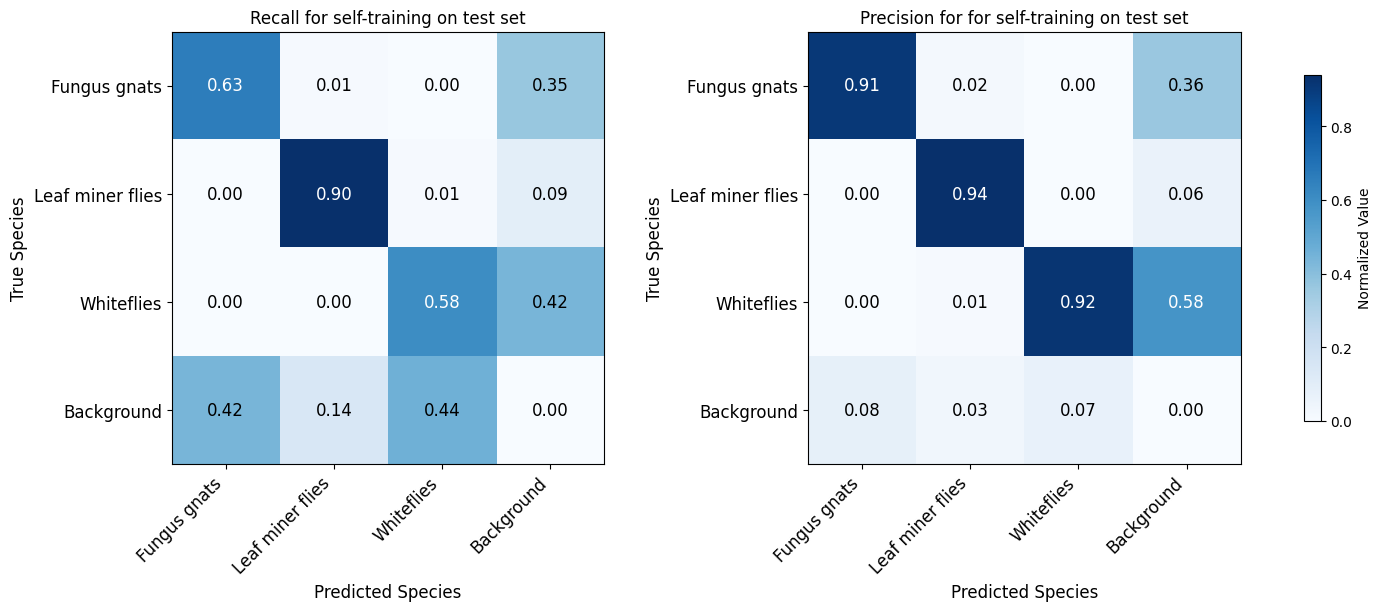

In [5]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_3_self_training_evaluation/metrics/train16_test_set/results.json"
_,_ = give_confusion_infos(file, species, label_map, "/user/christoph.wald/u15287/insect_pest_detection/3_3_self_training_evaluation/metrics/train16_test_set/confusion_selftrained_test.png", include_thrips=False)

### same on val

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 777   10    1  220]
 [   1 1002    6   52]
 [   0    7  843  634]
 [ 146   62  137    0]]


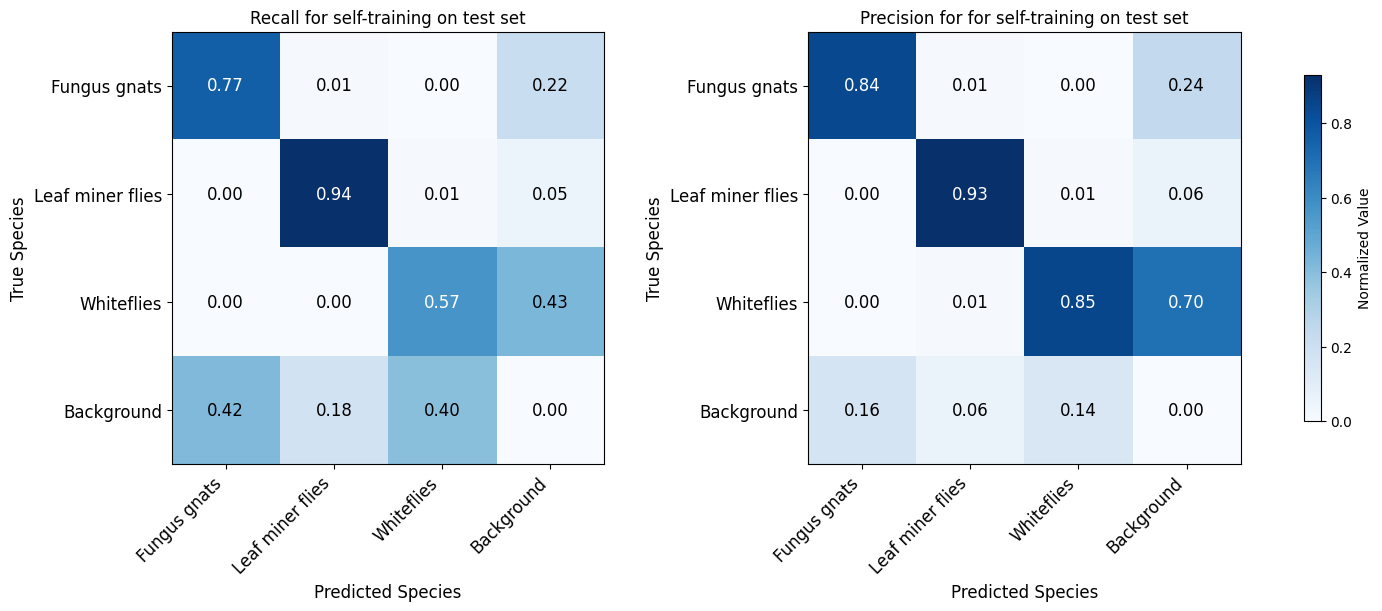

In [6]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_3_self_training_evaluation/metrics/train16/results.json"
_,_ = give_confusion_infos(file, species, label_map, "/user/christoph.wald/u15287/insect_pest_detection/3_3_self_training_evaluation/metrics/train16/confusion_selftrained_val.png", include_thrips=False)

### best self-training on tiles

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1349   28    0    6  668]
 [  14 1165    0   24  169]
 [   0    0    0    0    0]
 [   0    9    0 1892  822]
 [ 104   42    0  406    0]]


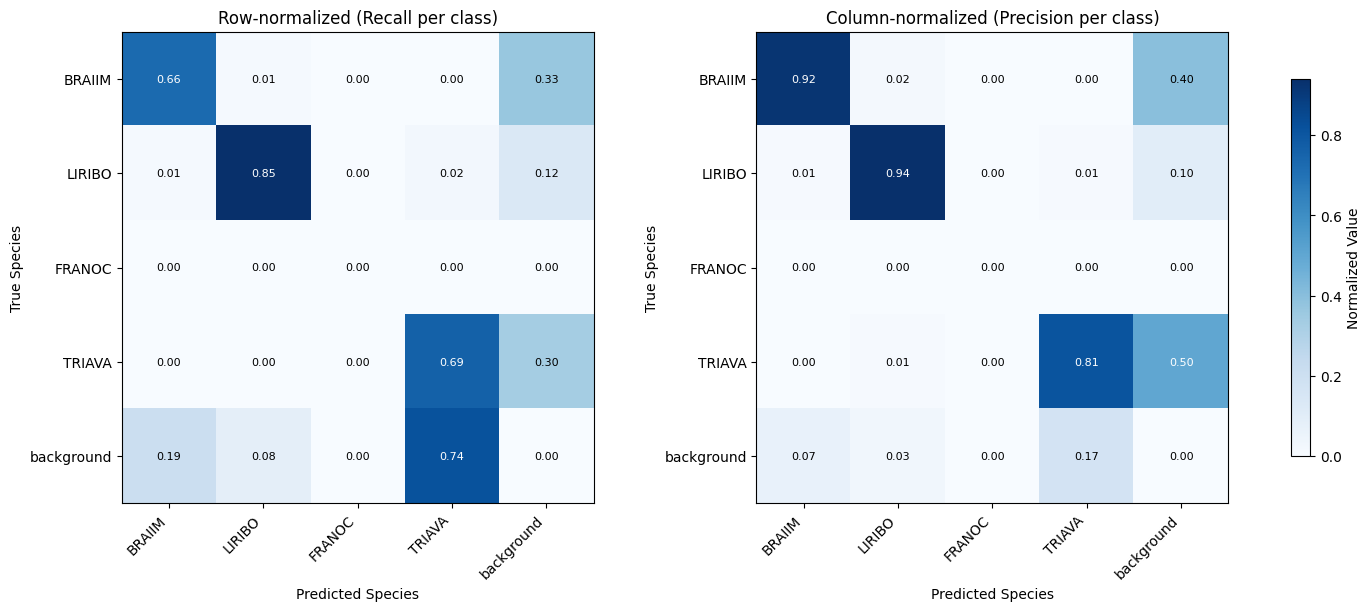

In [5]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_3_self_training_evaluation/metrics/train12_test_set/results.json"
c1, c2 = give_confusion_infos(file, "/user/christoph.wald/u15287/insect_pest_detection/3_3_self_training_evaluation/metrics/train12_test_set/confusion_self_trained.png")

### strictest mask with derived filter set 2 tested on train labeled

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1867    0    0 1833]
 [   0 2357    0 1540]
 [   0    0 1348 5079]
 [ 513  202  204    0]]


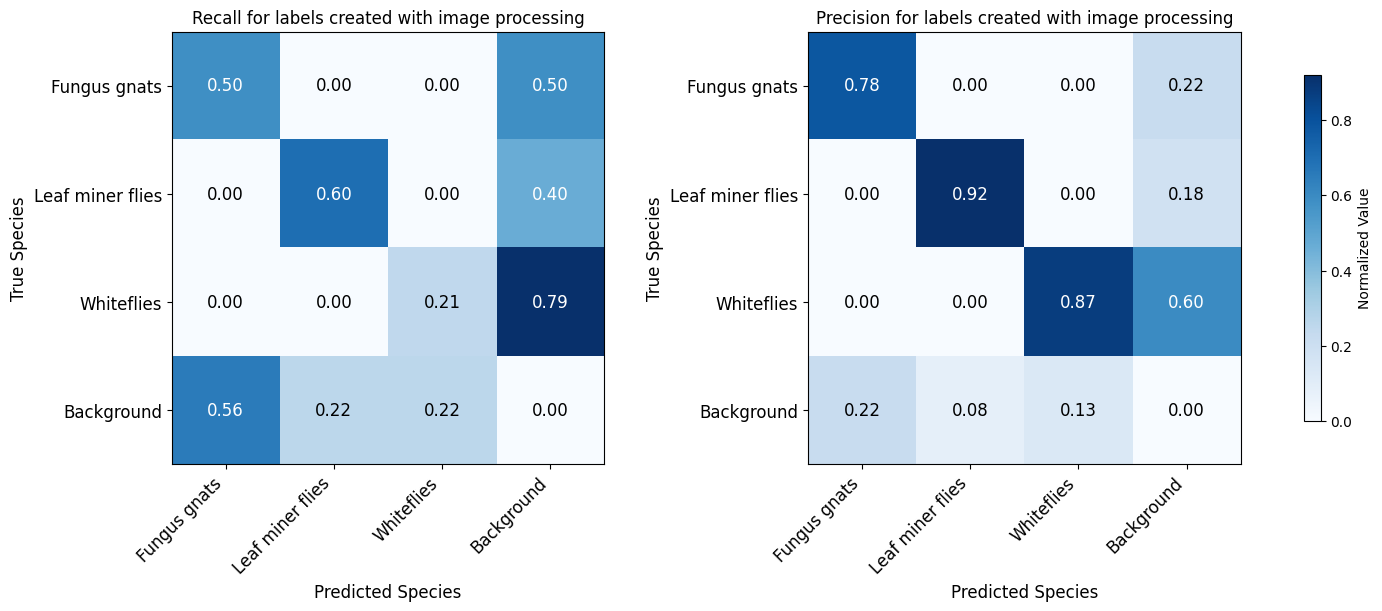

In [22]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_2_image_processing_evaluation/mask06_f2/results.json"
c1,c2 = give_confusion_infos(file, species, label_map, output_path = "/user/christoph.wald/u15287/insect_pest_detection/3_2_image_processing_evaluation/mask06_f2/confusion_matrix_mask06_f2.png", include_thrips=False)

### less stricter mask, same filter set

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1988    0    0    0 1712]
 [   0 2466    0    0 1431]
 [   0    0    0    0    0]
 [   0    0    0 1440 4987]
 [ 556  218    0  215    0]]


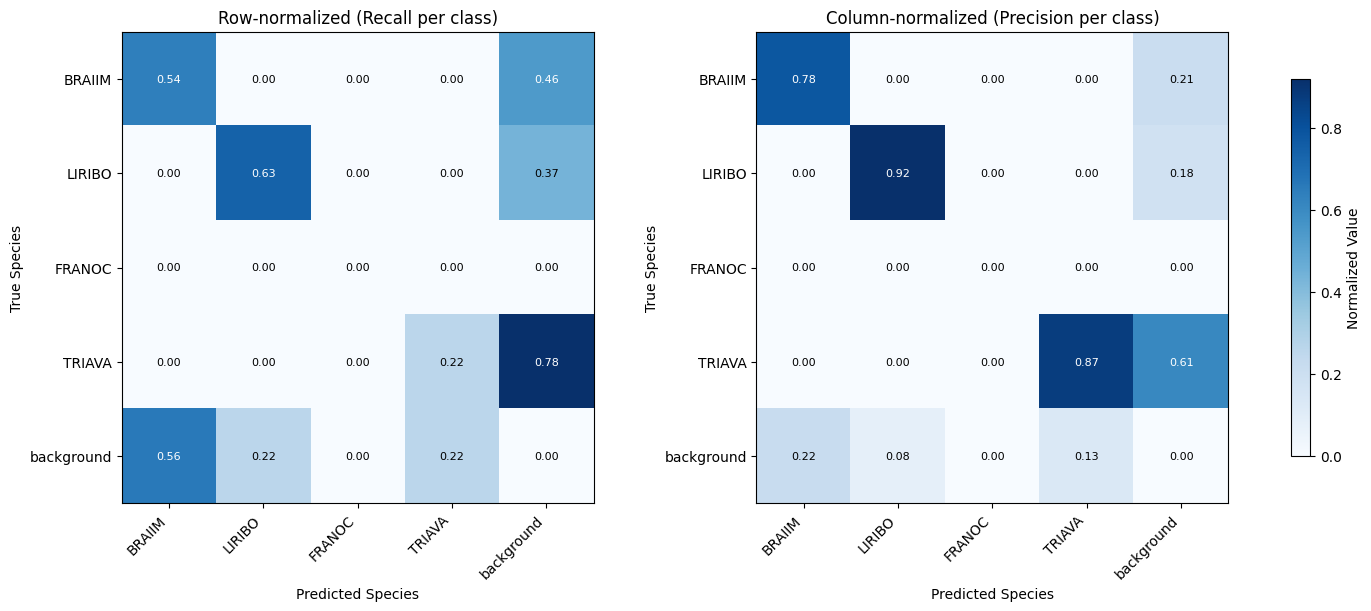

In [15]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_2_image_processing_evaluation/mask04_f2/results.json"
c1,c2 = give_confusion_infos(file, output_path =  "/user/christoph.wald/u15287/insect_pest_detection/3_2_image_processing_evaluation/mask04_f2/confusion_matrix_mask04_f2.png")